# Uncertainty Estimation for SMBH Hotspot Predictions

Two complementary approaches:

1. **Trilinear interpolation (Exp 6 / 7)** — Global, dataset-level σ estimates from the noise sweep grid.  
   Given your measurement uncertainties (σ_r, σ_T, σ_DPA), read off the expected prediction error for each target by interpolating over the trained 3×3×3 noise grid.

2. **Jacobian propagation (Exp 4 models)** — Sample-level σ estimates.  
   Analytic first-order (+ optional Hessian) uncertainty for a specific test sample, validated against Monte Carlo.

In [2]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import torch
from scipy.interpolate import RegularGridInterpolator

repo_root = Path("..")
sys.path.insert(0, str(repo_root))

from src.models.regression_head import RegressionHead
from src.utils.jacobian_uncertainty import (
    compute_jacobian, jacobian_sigma, mc_sigma, analyze_sample, aggregate_jacobian_results
)

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
print("Setup complete.")

Setup complete.


---
## Part 1 — Trilinear Interpolation (Exp 6 & 7)

Exp 6 = equatorial (spin, incl)  
Exp 7 = non-equatorial (spin, incl, theta, z)

Each combo CSV records the model's prediction error σ for a single noise level combination. We load all 27 combos and build a `RegularGridInterpolator` per target to query at arbitrary (σ_r, σ_T, σ_DPA) values.

In [3]:
# ── Configuration ────────────────────────────────────────────────────────────
EXP_CONFIGS = {
    6: dict(
        name="experiment_6_eq_noise_sweep",
        targets=["spin", "incl"],
        label="Exp VI — equatorial",
    ),
    7: dict(
        name="experiment_7_noneq_noise_sweep",
        targets=["spin", "incl", "theta", "z"],
        label="Exp VII — non-equatorial",
    ),
}

# Targets stored in radians → convert to degrees for display
RAD_TARGETS = {"incl", "theta"}
METRIC = "error_std"


def load_combo_df(exp_name: str) -> pd.DataFrame:
    """Load and concatenate all combo_*.csv files for one noise-sweep experiment."""
    combo_dir = repo_root / "results" / "metrics" / exp_name
    frames = []
    for p in sorted(combo_dir.glob("combo_*.csv")):
        frames.append(pd.read_csv(p))
    if not frames:
        raise FileNotFoundError(f"No combo_*.csv files found in {combo_dir}")
    df = pd.concat(frames, ignore_index=True)
    print(f"  Loaded {len(df)} rows from {len(frames)} combo files ({exp_name})")
    return df


def build_interpolators(df: pd.DataFrame, targets: list[str]) -> dict:
    """Build one RegularGridInterpolator per target from a merged combo DataFrame."""
    T_vals   = sorted(df["sigma_T"].unique())
    r_vals   = sorted(df["sigma_r"].unique())
    DPA_vals = sorted(df["sigma_DPA"].unique())

    T_idx   = {v: i for i, v in enumerate(T_vals)}
    r_idx   = {v: i for i, v in enumerate(r_vals)}
    DPA_idx = {v: i for i, v in enumerate(DPA_vals)}

    interps = {"_grid": (T_vals, r_vals, DPA_vals)}
    for target in targets:
        col = f"{target}_{METRIC}"
        arr = np.full((len(T_vals), len(r_vals), len(DPA_vals)), np.nan)
        for _, row in df.iterrows():
            arr[T_idx[row["sigma_T"]], r_idx[row["sigma_r"]], DPA_idx[row["sigma_DPA"]]] = row[col]
        if np.any(np.isnan(arr)):
            print(f"  WARNING ({target}): {np.sum(np.isnan(arr))} missing grid points")
        interps[target] = RegularGridInterpolator(
            (T_vals, r_vals, DPA_vals), arr,
            method="linear", bounds_error=False, fill_value=None
        )
    return interps


def query_interpolators(
    interps: dict,
    targets: list[str],
    sigma_r: float,
    sigma_T: float,
    sigma_DPA: float,
    label: str = "",
) -> dict:
    """Query all interpolators and print formatted results. Returns raw σ values."""
    point = np.array([[sigma_T, sigma_r, sigma_DPA]])
    results = {}
    hdr = f"{label}  (σ_r={sigma_r} M, σ_T={sigma_T} min, σ_DPA={sigma_DPA}°)"
    print(hdr)
    print("-" * len(hdr))
    for target in targets:
        sigma_raw = float(interps[target](point)[0])
        if target in RAD_TARGETS:
            sigma_disp = np.rad2deg(sigma_raw)
            unit = "deg"
        else:
            sigma_disp = sigma_raw
            unit = "" if target == "spin" else "M"
        print(f"  σ_{target:<6s} = {sigma_disp:.4f} {unit}")
        results[target] = (sigma_raw, sigma_disp, unit)
    print()
    return results


# Build interpolators for both experiments
interps = {}
for exp_id, cfg in EXP_CONFIGS.items():
    df_combo = load_combo_df(cfg["name"])
    interps[exp_id] = build_interpolators(df_combo, cfg["targets"])

  Loaded 27 rows from 27 combo files (experiment_6_eq_noise_sweep)
  Loaded 27 rows from 27 combo files (experiment_7_noneq_noise_sweep)


### 1a — Query example: GRAVITY+ typical noise levels

In [4]:
# ── Edit these to match your instrument / observation setup ──────────────────
SIGMA_R   = 0.3   # uncertainty in r [M]
SIGMA_T   = 1.0   # uncertainty in T [min]
SIGMA_DPA = 7.0   # uncertainty in DPA [deg]
# ─────────────────────────────────────────────────────────────────────────────

for exp_id, cfg in EXP_CONFIGS.items():
    query_interpolators(
        interps[exp_id], cfg["targets"],
        SIGMA_R, SIGMA_T, SIGMA_DPA,
        label=cfg["label"]
    )

Exp VI — equatorial  (σ_r=0.3 M, σ_T=1.0 min, σ_DPA=7.0°)
---------------------------------------------------------
  σ_spin   = 0.1571 
  σ_incl   = 3.9493 deg

Exp VII — non-equatorial  (σ_r=0.3 M, σ_T=1.0 min, σ_DPA=7.0°)
--------------------------------------------------------------
  σ_spin   = 0.2276 
  σ_incl   = 4.5595 deg
  σ_theta  = 9.9369 deg
  σ_z      = 1.3588 M



### 1b — Heatmaps: expected σ over the noise grid (Exp 6 equatorial)

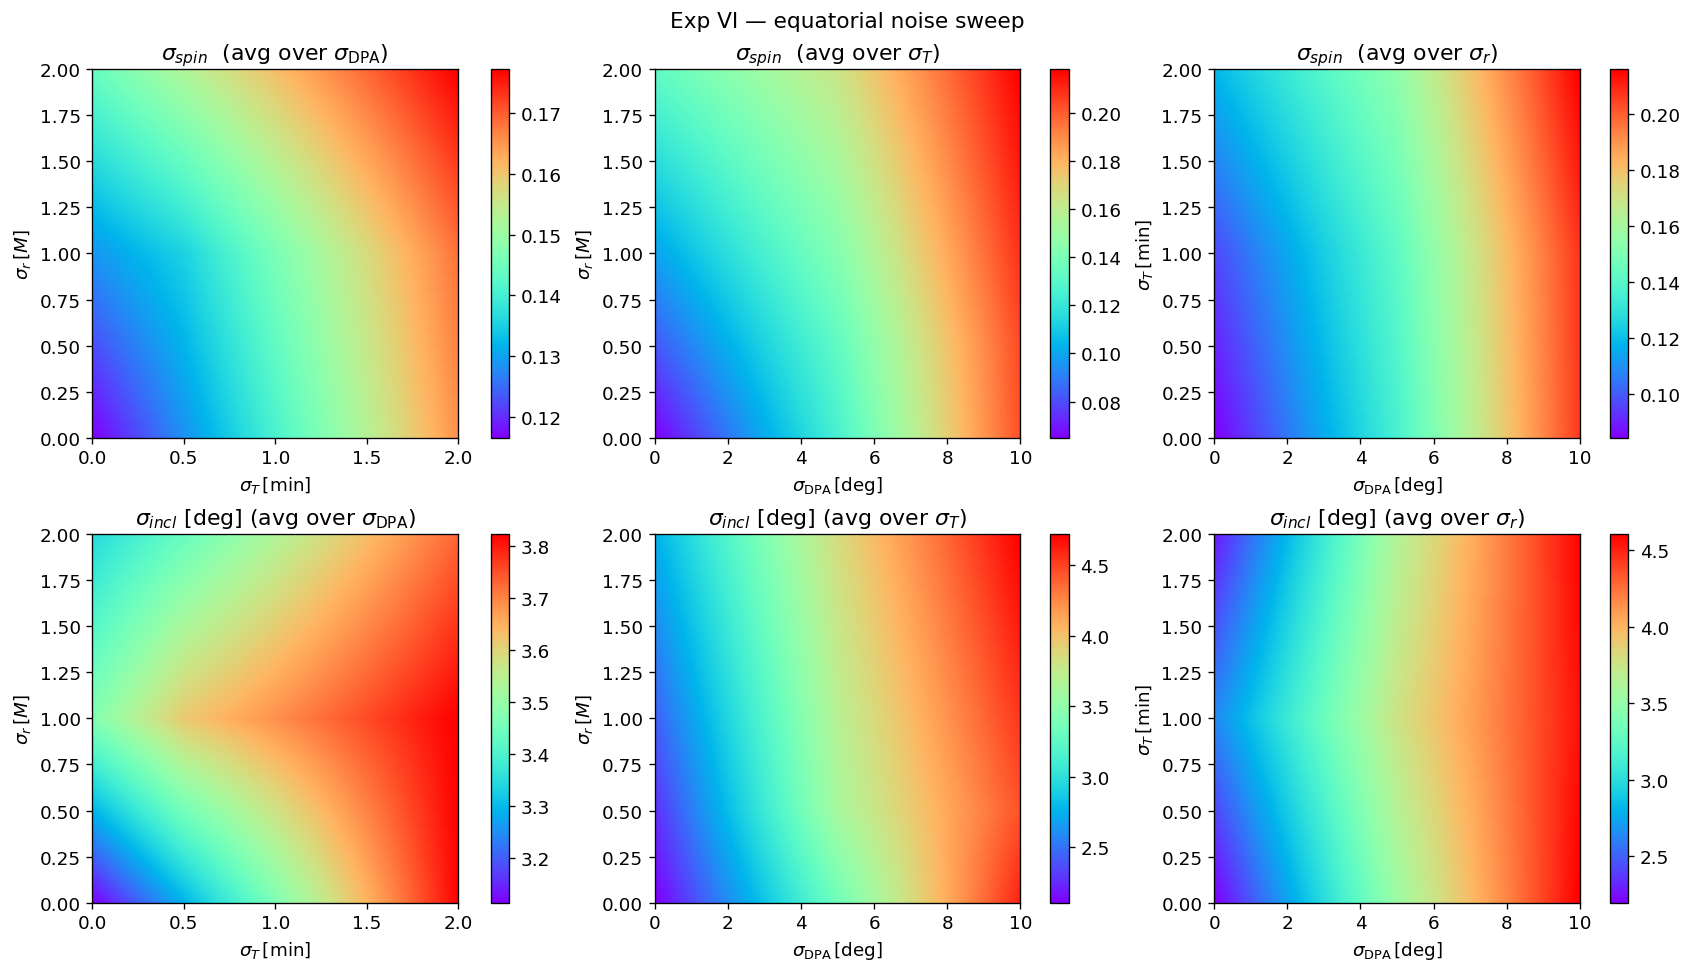

In [14]:
def plot_noise_heatmaps(interps: dict, targets: list[str], title: str, 
                       dense_factor: int = 64):
    """
    For each target: three heatmaps averaging over the third noise axis.
    Interpolates to a denser grid between points.
    Args:
        interps: dict of {target: interpolator, "_grid": (T_vals, r_vals, DPA_vals)}
        targets: list of target names (str)
        title: plot title
        dense_factor: how many times denser to interpolate grid (default 4)
    """
    T_vals, r_vals, DPA_vals = interps["_grid"]
    nT, nr, nDPA = len(T_vals), len(r_vals), len(DPA_vals)

    # --- Interpolate a denser grid in each axis ---
    T_dense = np.linspace(T_vals[0], T_vals[-1], nT * dense_factor)
    r_dense = np.linspace(r_vals[0], r_vals[-1], nr * dense_factor)
    DPA_dense = np.linspace(DPA_vals[0], DPA_vals[-1], nDPA * dense_factor)
    nT_d, nr_d, nDPA_d = len(T_dense), len(r_dense), len(DPA_dense)

    n_targets = len(targets)
    fig, axes = plt.subplots(
        n_targets, 3, figsize=(14, 4 * n_targets),
        constrained_layout=True
    )
    if n_targets == 1:
        axes = axes[np.newaxis, :]

    fig.suptitle(title, fontsize=13)

    for row_i, target in enumerate(targets):
        interp = interps[target]

        # Evaluate interpolator on the dense grid
        TT, RR, DD = np.meshgrid(T_dense, r_dense, DPA_dense, indexing="ij")
        pts = np.column_stack([TT.ravel(), RR.ravel(), DD.ravel()])
        vals = interp(pts).reshape(nT_d, nr_d, nDPA_d)

        if target in RAD_TARGETS:
            vals = np.rad2deg(vals)
            display_unit = r"\mathrm{[deg]}"
        elif target == "z":
            display_unit = r"\mathrm{[M]}"
        else:
            display_unit = ""

        # 1) σ_r vs σ_T (averaged over DPA)
        ax = axes[row_i, 0]
        im = ax.imshow(
            vals.mean(axis=2),
            origin="lower", aspect="auto",
            extent=[T_dense[0], T_dense[-1], r_dense[0], r_dense[-1]],
            cmap="rainbow"
        )
        ax.set_xlabel(r"$\sigma_T\, [\mathrm{min}]$")
        ax.set_ylabel(r"$\sigma_r\, [M]$")
        ax.set_title(fr"$\sigma_{{{target}}}\ {display_unit}$ (avg over $\sigma_{{\mathrm{{DPA}}}}$)")
        plt.colorbar(im, ax=ax)

        # 2) σ_r vs σ_DPA (averaged over T)
        ax = axes[row_i, 1]
        im = ax.imshow(
            vals.mean(axis=0),
            origin="lower", aspect="auto",
            extent=[DPA_dense[0], DPA_dense[-1], r_dense[0], r_dense[-1]],
            cmap="rainbow"
        )
        ax.set_xlabel(r"$\sigma_{\mathrm{DPA}}\, [\mathrm{deg}]$")
        ax.set_ylabel(r"$\sigma_r\, [M]$")
        ax.set_title(fr"$\sigma_{{{target}}}\ {display_unit}$ (avg over $\sigma_T$)")
        plt.colorbar(im, ax=ax)

        # 3) σ_T vs σ_DPA (averaged over r)
        ax = axes[row_i, 2]
        im = ax.imshow(
            vals.mean(axis=1),
            origin="lower", aspect="auto",
            extent=[DPA_dense[0], DPA_dense[-1], T_dense[0], T_dense[-1]],
            cmap="rainbow"
        )
        ax.set_xlabel(r"$\sigma_{\mathrm{DPA}}\, [\mathrm{deg}]$")
        ax.set_ylabel(r"$\sigma_T\, [\mathrm{min}]$")
        ax.set_title(fr"$\sigma_{{{target}}}\ {display_unit}$ (avg over $\sigma_r$)")
        plt.colorbar(im, ax=ax)

    plt.show()


plot_noise_heatmaps(interps[6], EXP_CONFIGS[6]["targets"], "Exp VI — equatorial noise sweep")

### 1c — Heatmaps: Exp 7 non-equatorial (4 targets)

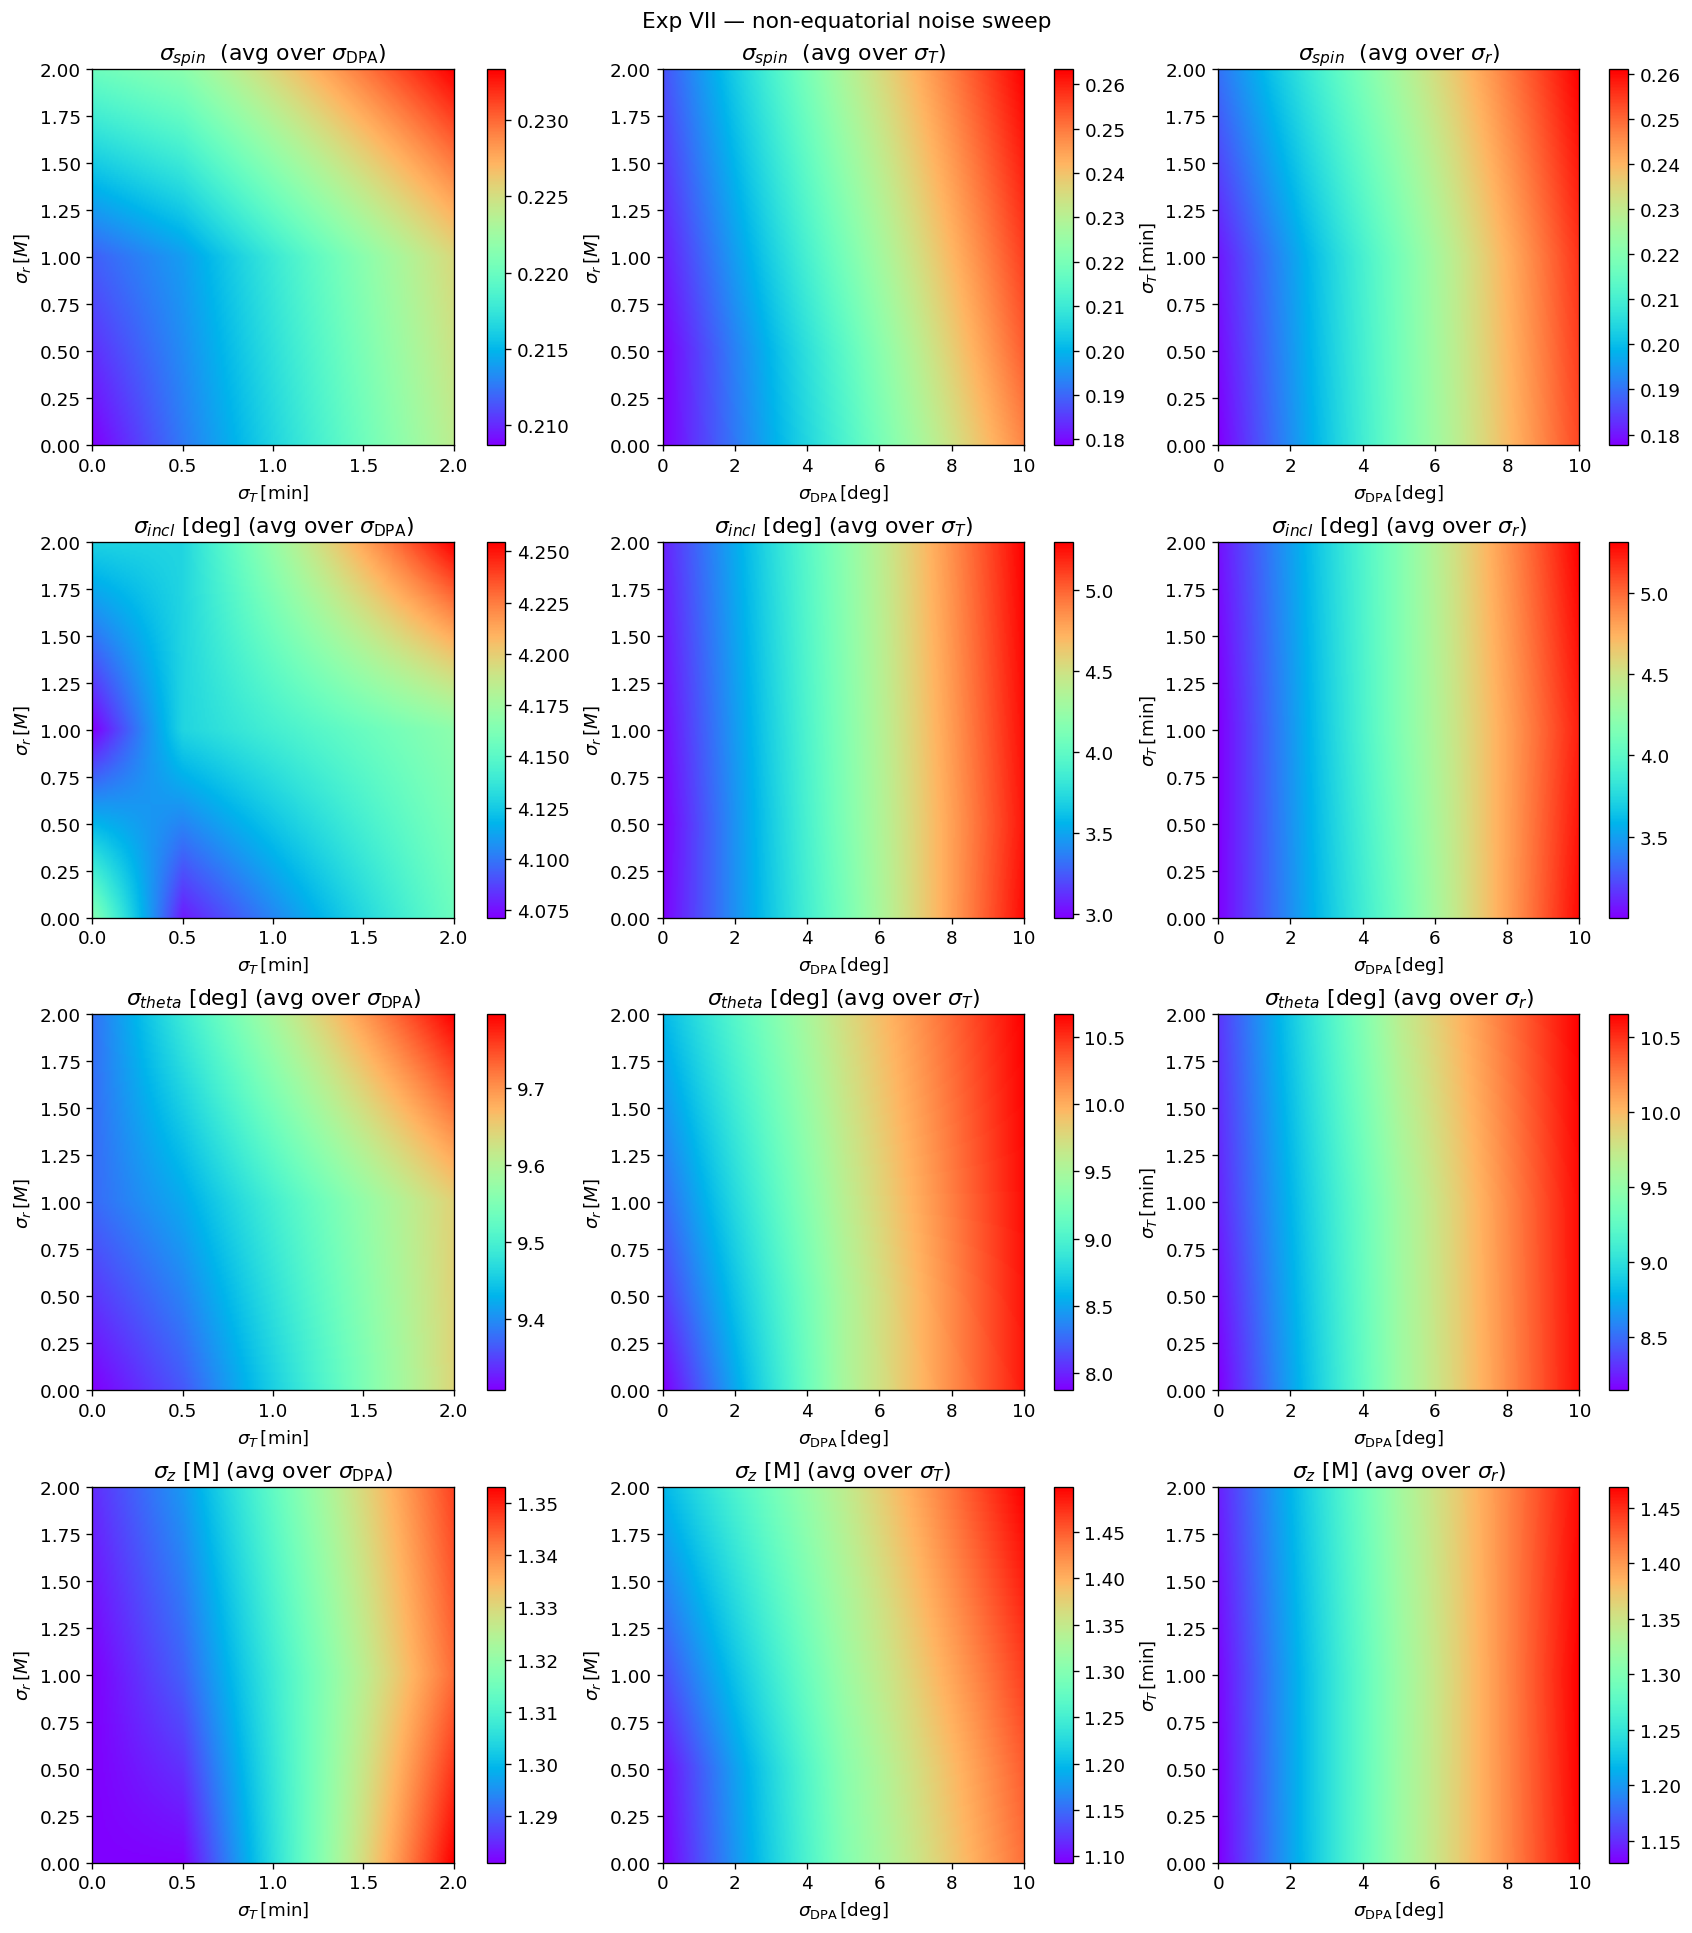

In [15]:
plot_noise_heatmaps(interps[7], EXP_CONFIGS[7]["targets"], "Exp VII — non-equatorial noise sweep")

---
## Part 2 — Jacobian Uncertainty (Exp 4 models)

Exp 4 = non-equatorial, full orbit (4 targets: spin, incl, theta, z).  
We load the saved checkpoint (which contains the StandardScaler parameters) and the `test_details` CSV, then run the Jacobian analysis on individual test samples.

**Note:** experiments 8 & 9 are the designated Jacobian experiments but their training code is not yet implemented. The Exp 4 models are the appropriate ones to use in the meantime.

In [36]:
# ── Configuration ────────────────────────────────────────────────────────────
JACOBIAN_EXP    = "experiment_4_noneq_full"  # change to experiment_2_eq_full for equatorial
JACOBIAN_TARGET = "spin"                      # one of: spin, incl, theta, z
SEED            = 42
N_DISPLAY       = 5      # number of test samples to display in detail

# Measurement uncertainties (original units, before z-normalization)
#   r: units of M, T: minutes, DPA: degrees
SIGMA_OBS = dict(sigma_r=0.6, sigma_T=5.0, sigma_DPA=10.0)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

Using device: cpu


In [37]:
def load_checkpoint(exp_name: str, target: str, seed: int) -> dict:
    ckpt_path = (
        repo_root / "results" / "checkpoints" / exp_name / target / f"model_seed{seed}.pth"
    )
    ckpt = torch.load(ckpt_path, map_location="cpu", weights_only=False)
    print(f"Loaded checkpoint: {ckpt_path.relative_to(repo_root)}")
    return ckpt


def load_model(ckpt: dict, input_dim: int, device: str) -> RegressionHead:
    model = RegressionHead(
        input_dim=input_dim,
        hidden_dims=(256, 256),
        num_blocks=2,
        dropout=0.1,
    ).to(device)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()
    return model


def load_test_details(exp_name: str, seed: int) -> pd.DataFrame:
    csv_path = repo_root / "results" / "metrics" / exp_name / f"test_details_seed{seed}.csv"
    df = pd.read_csv(csv_path)
    print(f"Loaded test details: {csv_path.relative_to(repo_root)} ({len(df)} samples)")
    return df


# ── Load checkpoint ───────────────────────────────────────────────────────────
ckpt = load_checkpoint(JACOBIAN_EXP, JACOBIAN_TARGET, SEED)

# Input dimension: 2 (r, T) + 10 DPA time-series samples = 12
INPUT_DIM = 12
model = load_model(ckpt, INPUT_DIM, DEVICE)

# Scaler parameters stored in checkpoint
scaler_X_mean  = ckpt["scaler_X_mean"]   # shape (input_dim,)
scaler_X_scale = ckpt["scaler_X_scale"]  # shape (input_dim,)

# Avoid deprecated float conversion warnings — explicitly extract scalar if needed
def extract_scalar(arr):
    if hasattr(arr, 'shape') and arr.shape == ():
        return float(arr)
    if hasattr(arr, '__len__') and len(arr) == 1:
        return float(arr[0])
    # fallback for typical case of ndarray shape () or []
    return float(np.array(arr).item()) if hasattr(arr, 'item') and arr.shape == () else float(arr)

scaler_y_mean  = extract_scalar(ckpt["scaler_y_mean"])
scaler_y_scale = extract_scalar(ckpt["scaler_y_scale"])

print(f"\nScaler_X_mean  : {scaler_X_mean}")
print(f"Scaler_X_scale : {scaler_X_scale}")
print(f"Scaler_y_mean  : {scaler_y_mean:.6f}")
print(f"Scaler_y_scale : {scaler_y_scale:.6f}")

Loaded checkpoint: results/checkpoints/experiment_4_noneq_full/spin/model_seed42.pth

Scaler_X_mean  : [  7.81955568  53.5790109  124.18487712 124.25140244 124.42039411
 124.59145157 124.61142366 124.72230439 124.83818028 124.78852673
 124.39661313 124.20658741]
Scaler_X_scale : [ 2.15438686 21.07930554 39.33155209 39.05364068 38.91874455 39.29249238
 39.26428862 39.40916864 39.53851181 39.27448117 39.03025225 39.63350719]
Scaler_y_mean  : 0.025138
Scaler_y_scale : 0.565846


In [38]:
# ── Load test details CSV ─────────────────────────────────────────────────────
df_test = load_test_details(JACOBIAN_EXP, SEED)
df_test.head(3)

Loaded test details: results/metrics/experiment_4_noneq_full/test_details_seed42.csv (4801 samples)


,sample_idx,spin_true,spin_pred,spin_error,incl_true,incl_pred,incl_error,theta_true,theta_pred,theta_error,z_true,z_pred,z_error
0,0,-0.04,0.087334,-0.127334,0.938987,0.869607,0.069380,-0.017453,0.033108,-0.050561,-0.137874,0.480347,-0.618221
1,1,0.78,0.757304,0.022696,0.862193,0.803738,0.058454,0.261799,0.404045,-0.142246,1.578796,1.908176,-0.329380
2,2,-0.28,-0.550834,0.270834,0.052360,0.074641,-0.022282,0.436332,0.253011,0.183321,4.606539,2.930421,1.676118


In [39]:
# ── Reconstruct raw (un-normalised) test features from the dataset CSV ────────
#
# The test_details CSV only stores per-target predictions and errors, not the
# raw input features.  We need to reload the processed dataset and apply the
# same split (seed=42) to recover the test-set feature vectors.
#
# ×10 encoding note: r, i, theta, z are stored at 10× physical values in the
# CSV (see memory: project_dat_convention).

from src.training.data_loader import build_features_targets_timeseries, prepare_dataloaders

DATASET_PATH = repo_root / "data" / "processed" / "dpa_dataset_noneq.csv"  # Exp 4

df_raw = pd.read_csv(DATASET_PATH)
print(f"Dataset shape: {df_raw.shape}")
print(f"Columns: {list(df_raw.columns[:8])} ...")

# Build features/targets for the target we're analyzing
TARGET_COLUMN = {
    "spin":  "a",
    "incl":  "i",
    "theta": "theta",
    "z":     "z",
}[JACOBIAN_TARGET]

convert_rad = JACOBIAN_TARGET in {"incl", "theta", "z"}

features, targets, _ = build_features_targets_timeseries(
    df_raw,
    target_name=JACOBIAN_TARGET,
    target_column=TARGET_COLUMN,
    num_samples=10,
    convert_to_radians=convert_rad,
    half_orbit=False,
    random_seed=SEED,
)

# Reproduce the same train/val/test split — no noise, just to get X_test_raw
_, _, test_loader, _, _, (train_idx, val_idx, test_idx) = prepare_dataloaders(
    features, targets,
    batch_size=256,
    train_ratio=0.8,
    val_ratio=0.1,
    random_seed=SEED,
    noise_enabled=False,
)

X_test_raw = features[test_idx]  # (n_test, 12)
y_test_raw = targets[test_idx]   # (n_test,)

print(f"\nTest set size: {len(X_test_raw)}")
print(f"Feature shape: {X_test_raw.shape}")

# Sanity check: re-derive predictions and compare to CSV
x_norm = (X_test_raw - scaler_X_mean) / scaler_X_scale
x_tensor = torch.tensor(x_norm, dtype=torch.float32).to(DEVICE)
with torch.no_grad():
    y_pred_norm = model(x_tensor).cpu().numpy().squeeze()
y_pred_check = y_pred_norm * scaler_y_scale + scaler_y_mean

csv_pred = df_test[f"{JACOBIAN_TARGET}_pred"].values
mae_recon = np.mean(np.abs(y_pred_check - csv_pred))
print(f"\nReconstruction check — MAE between recomputed and CSV preds: {mae_recon:.6f}")
print("(Should be near 0 if the split is correctly reproduced.)")

Dataset shape: (48001, 16)
Columns: ['r', 'K', 'a', 'i', 'theta', 'Period', 'DPA_0.1', 'DPA_0.2'] ...



Test set size: 4801
Feature shape: (4801, 12)

Reconstruction check — MAE between recomputed and CSV preds: 0.071830
(Should be near 0 if the split is correctly reproduced.)


### 2a — Per-sample Jacobian analysis: detailed view of N samples

In [40]:
# Build the sigma_obs vector: same σ for each DPA channel, σ_r for r, σ_T for T.
#   Feature layout: [r, T, DPA_0, DPA_1, ..., DPA_9]
#
# ×10 encoding: raw features have r stored as 10×physical and T in minutes
# (T is not multiplied). σ_r must therefore also be ×10 to match.

sigma_r_raw   = SIGMA_OBS["sigma_r"] * 10.0   # ×10 to match encoding
sigma_T_raw   = SIGMA_OBS["sigma_T"]           # [min], no scaling
sigma_DPA_raw = SIGMA_OBS["sigma_DPA"]         # [deg], no scaling

sigma_obs_vec = np.array(
    [sigma_r_raw, sigma_T_raw]
    + [sigma_DPA_raw] * 10,
    dtype=np.float32
)

print(f"σ_obs vector (first 4 entries): {sigma_obs_vec[:4]}")
print(f"σ_obs vector (all {len(sigma_obs_vec)} features): {np.round(sigma_obs_vec, 3)}")

σ_obs vector (first 4 entries): [ 6.  5. 10. 10.]
σ_obs vector (all 12 features): [ 6.  5. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10.]


In [41]:
print(f"Analyzing {N_DISPLAY} test samples — target: {JACOBIAN_TARGET}")
print("=" * 70)

sample_records = []
for i in range(N_DISPLAY):
    result = analyze_sample(
        model=model,
        x_orig_1d=X_test_raw[i],
        sigma_obs_orig=sigma_obs_vec,
        scaler_X_mean=scaler_X_mean,
        scaler_X_scale=scaler_X_scale,
        scaler_y_mean=scaler_y_mean,
        scaler_y_scale=scaler_y_scale,
        n_mc=2000,
        device=DEVICE,
    )

    true_val = float(y_test_raw[i])
    pred_val = float(df_test[f"{JACOBIAN_TARGET}_pred"].iloc[i])
    error    = float(df_test[f"{JACOBIAN_TARGET}_error"].iloc[i])
    sigma_j  = result["sigma_jacobian"]
    sigma_mc = result["sigma_mc"]

    # Convert to degrees for angular targets
    disp_unit = "(rad)"
    if JACOBIAN_TARGET in RAD_TARGETS:
        true_disp = np.rad2deg(true_val)
        pred_disp = np.rad2deg(pred_val)
        err_disp  = np.rad2deg(error)
        sj_disp   = np.rad2deg(sigma_j)
        smc_disp  = np.rad2deg(sigma_mc)
        disp_unit = "(deg)"
    else:
        true_disp, pred_disp, err_disp, sj_disp, smc_disp = (
            true_val, pred_val, error, sigma_j, sigma_mc
        )

    print(f"Sample {i:4d} {disp_unit}")
    print(f"  True             : {true_disp:+.4f}")
    print(f"  Pred             : {pred_disp:+.4f}")
    print(f"  Error            : {err_disp:+.4f}")
    print(f"  σ_jacobian       : ±{sj_disp:.4f}")
    print(f"  σ_mc (N=2000)    : ±{smc_disp:.4f}")
    print(f"  Ratio J/MC       : {result['ratio']:.3f}")
    print(f"  Hessian corr.    : {result['hessian_correction_pct']:.1f}%")
    print(f"  Method selected  : {result['method']}")
    print()

    sample_records.append({
        "sample_idx":    i,
        "true":          true_disp,
        "pred":          pred_disp,
        "error":         err_disp,
        "sigma_jacobian": sj_disp,
        "sigma_mc":      smc_disp,
        "ratio":         result["ratio"],
        "hessian_pct":   result["hessian_correction_pct"],
        "method":        result["method"],
    })

df_samples = pd.DataFrame(sample_records)
df_samples

Analyzing 5 test samples — target: spin
Sample    0 (rad)
  True             : -0.0400
  Pred             : +0.0873
  Error            : -0.1273
  σ_jacobian       : ±0.5949
  σ_mc (N=2000)    : ±0.3781
  Ratio J/MC       : 1.573
  Hessian corr.    : 0.0%
  Method selected  : suspicious

Sample    1 (rad)
  True             : +0.7800
  Pred             : +0.7573
  Error            : +0.0227
  σ_jacobian       : ±0.4780
  σ_mc (N=2000)    : ±0.3873
  Ratio J/MC       : 1.234
  Hessian corr.    : 0.0%
  Method selected  : suspicious

Sample    2 (rad)
  True             : -0.2800
  Pred             : -0.5508
  Error            : +0.2708
  σ_jacobian       : ±0.5312
  σ_mc (N=2000)    : ±0.2213
  Ratio J/MC       : 2.400
  Hessian corr.    : 0.0%
  Method selected  : suspicious

Sample    3 (rad)
  True             : -0.4000
  Pred             : -0.6079
  Error            : +0.2079
  σ_jacobian       : ±1.3940
  σ_mc (N=2000)    : ±0.2102
  Ratio J/MC       : 6.632
  Hessian corr.    : 0.

,sample_idx,true,pred,error,sigma_jacobian,sigma_mc,ratio,hessian_pct,method
0,0,-0.04,0.087334,-0.127334,0.594906,0.378098,1.573416,0.0,suspicious
1,1,0.78,0.757304,0.022696,0.477982,0.387274,1.234222,0.0,suspicious
2,2,-0.28,-0.550834,0.270834,0.531162,0.221330,2.399869,0.0,suspicious
3,3,-0.40,-0.607939,0.207939,1.394036,0.210206,6.631758,0.0,suspicious
4,4,0.16,0.160306,-0.000306,0.436291,0.301003,1.449458,0.0,suspicious


### 2b — Prediction ± Jacobian σ visualization

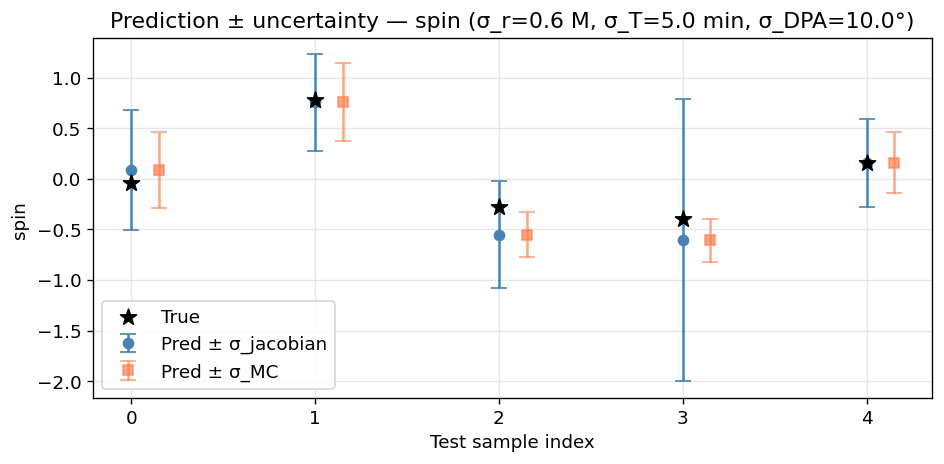

In [42]:
fig, ax = plt.subplots(figsize=(8, 4))

xs = df_samples["sample_idx"].values
ax.scatter(xs, df_samples["true"],  marker="*", s=100, zorder=5,
           label="True", color="k")
ax.errorbar(
    xs, df_samples["pred"],
    yerr=df_samples["sigma_jacobian"],
    fmt="o", capsize=5, color="steelblue",
    label="Pred ± σ_jacobian", zorder=4
)
ax.errorbar(
    xs + 0.15, df_samples["pred"],
    yerr=df_samples["sigma_mc"],
    fmt="s", capsize=5, color="coral",
    label="Pred ± σ_MC", zorder=3, alpha=0.7
)

unit_label = "[deg]" if JACOBIAN_TARGET in RAD_TARGETS else ""
ax.set_xlabel("Test sample index")
ax.set_ylabel(f"{JACOBIAN_TARGET} {unit_label}")
ax.set_title(
    f"Prediction ± uncertainty — {JACOBIAN_TARGET} "
    f"(σ_r={SIGMA_OBS['sigma_r']} M, σ_T={SIGMA_OBS['sigma_T']} min, "
    f"σ_DPA={SIGMA_OBS['sigma_DPA']}°)"
)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 2c — Jacobian feature attribution: which inputs drive uncertainty?

The normalised Jacobian |J_i| × (σ_obs_i / σ_X_i) gives the per-feature contribution to the total propagated uncertainty.

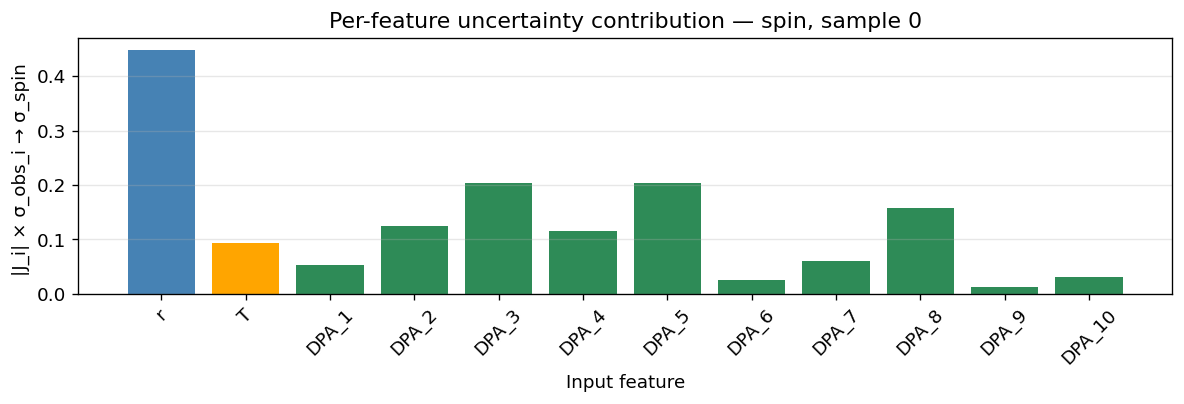

Total σ (quadrature sum) = 0.59491 
Top 3 contributing features:
  1. r           0.44825
  2. DPA_3       0.20355
  3. DPA_5       0.20284


In [43]:
# Pick one sample to inspect in detail
SAMPLE_IDX = 0

x_norm = (X_test_raw[SAMPLE_IDX] - scaler_X_mean) / scaler_X_scale
x_tensor_1d = torch.tensor(x_norm, dtype=torch.float32).to(DEVICE)

J_norm = compute_jacobian(model, x_tensor_1d).cpu().numpy()
sigma_x_norm = sigma_obs_vec / scaler_X_scale

# Per-feature uncertainty contribution (in normalised space)
contributions_norm = np.abs(J_norm) * sigma_x_norm

# Back-scale to original target units
contributions = contributions_norm * scaler_y_scale

feature_names = ["r", "T"] + [f"DPA_{k+1}" for k in range(10)]

fig, ax = plt.subplots(figsize=(10, 3.5))
colors_bar = ["steelblue", "orange"] + ["seagreen"] * 10
bars = ax.bar(feature_names, contributions, color=colors_bar)
ax.set_xlabel("Input feature")
unit_label = "[deg]" if JACOBIAN_TARGET in RAD_TARGETS else ""
ax.set_ylabel(f"|J_i| × σ_obs_i → σ_{JACOBIAN_TARGET} {unit_label}")
ax.set_title(
    f"Per-feature uncertainty contribution — "
    f"{JACOBIAN_TARGET}, sample {SAMPLE_IDX}"
)
ax.tick_params(axis="x", rotation=45)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

print(f"Total σ (quadrature sum) = {np.sqrt(np.sum(contributions**2)):.5f} {unit_label}")
print(f"Top 3 contributing features:")
top3 = np.argsort(contributions)[::-1][:3]
for rank, fi in enumerate(top3):
    print(f"  {rank+1}. {feature_names[fi]:<10s}  {contributions[fi]:.5f}")

### 2d — Batch Jacobian analysis across all test samples

In [44]:
# ⚠ This cell can take several minutes depending on hardware and test set size.
# Set N_BATCH_SAMPLES to a smaller value (e.g. 100) for a quick run.
N_BATCH_SAMPLES = len(X_test_raw)   # set to e.g. 200 to speed up

print(f"Running Jacobian analysis on {N_BATCH_SAMPLES} test samples...")

batch_records = []
batch_jacobians = []

for i in range(N_BATCH_SAMPLES):
    if i % 100 == 0:
        print(f"  {i}/{N_BATCH_SAMPLES}", flush=True)

    result = analyze_sample(
        model=model,
        x_orig_1d=X_test_raw[i],
        sigma_obs_orig=sigma_obs_vec,
        scaler_X_mean=scaler_X_mean,
        scaler_X_scale=scaler_X_scale,
        scaler_y_mean=scaler_y_mean,
        scaler_y_scale=scaler_y_scale,
        n_mc=500,    # reduced for batch speed; use 2000 for final results
        device=DEVICE,
    )
    batch_records.append({
        "sample_idx":          i,
        "y_true":              float(y_test_raw[i]),
        "y_pred":              float(df_test[f"{JACOBIAN_TARGET}_pred"].iloc[i]),
        "sigma_jacobian":      result["sigma_jacobian"],
        "sigma_mc":            result["sigma_mc"],
        "ratio":               result["ratio"],
        "hessian_correction_pct": result["hessian_correction_pct"],
        "method":              result["method"],
    })
    batch_jacobians.append(result["J_norm"])

df_batch = pd.DataFrame(batch_records)
jacobians_array = np.array(batch_jacobians)  # (N_BATCH, 12)

# Aggregate stats
agg = aggregate_jacobian_results(batch_records, JACOBIAN_TARGET)
print("\n── Aggregate statistics ──")
for k, v in agg.items():
    print(f"  {k:<35s}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

Running Jacobian analysis on 4801 test samples...
  0/4801
  100/4801
  200/4801
  300/4801
  400/4801
  500/4801
  600/4801
  700/4801
  800/4801
  900/4801
  1000/4801
  1100/4801
  1200/4801
  1300/4801
  1400/4801
  1500/4801
  1600/4801
  1700/4801
  1800/4801
  1900/4801
  2000/4801
  2100/4801
  2200/4801
  2300/4801
  2400/4801
  2500/4801
  2600/4801
  2700/4801
  2800/4801
  2900/4801
  3000/4801
  3100/4801
  3200/4801
  3300/4801
  3400/4801
  3500/4801
  3600/4801
  3700/4801
  3800/4801
  3900/4801
  4000/4801
  4100/4801
  4200/4801
  4300/4801
  4400/4801
  4500/4801
  4600/4801
  4700/4801
  4800/4801

── Aggregate statistics ──
  target: spin
  ratio_mean                         : 3.3808
  ratio_std                          : 2.3979
  frac_reliable                      : 0.0392
  hessian_correction_mean            : 0.0000
  sigma_jacobian_mean                : 1.1697
  sigma_mc_mean                      : 0.3487


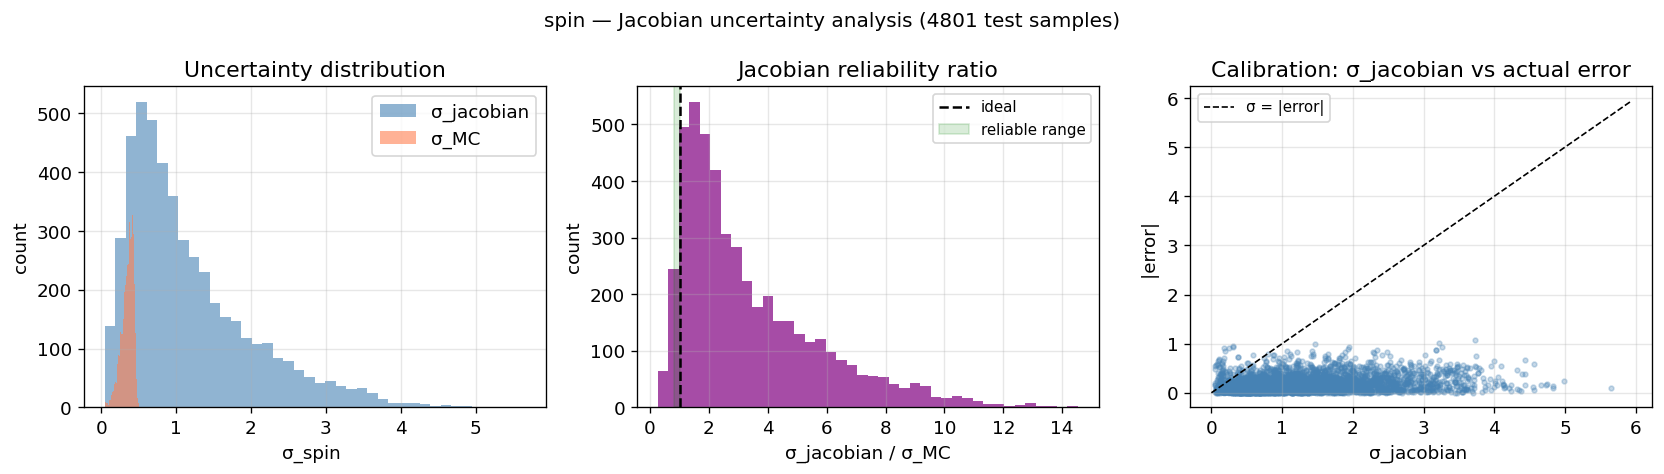


Method selected per sample:
method
suspicious          4465
jacobian             188
jacobian+hessian     148
Name: count, dtype: int64


In [45]:
# Distribution of σ_jacobian and σ_mc across test set
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

disp_scale = np.rad2deg(1.0) if JACOBIAN_TARGET in RAD_TARGETS else 1.0
unit_label  = "[deg]" if JACOBIAN_TARGET in RAD_TARGETS else ""

sj = df_batch["sigma_jacobian"].values * disp_scale
sm = df_batch["sigma_mc"].values * disp_scale
ratios = df_batch["ratio"].values

# σ distributions
axes[0].hist(sj, bins=40, alpha=0.6, label="σ_jacobian", color="steelblue")
axes[0].hist(sm, bins=40, alpha=0.6, label="σ_MC",       color="coral")
axes[0].set_xlabel(f"σ_{JACOBIAN_TARGET} {unit_label}")
axes[0].set_ylabel("count")
axes[0].set_title("Uncertainty distribution")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Jacobian/MC ratio
axes[1].hist(ratios[np.isfinite(ratios)], bins=40, color="purple", alpha=0.7)
axes[1].axvline(1.0, color="k", linestyle="--", label="ideal")
axes[1].axvspan(0.8, 1.0, alpha=0.15, color="green", label="reliable range")
axes[1].set_xlabel("σ_jacobian / σ_MC")
axes[1].set_ylabel("count")
axes[1].set_title("Jacobian reliability ratio")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

# σ_jacobian vs |error| scatter
errors = np.abs(df_batch["y_true"].values - df_batch["y_pred"].values) * disp_scale
axes[2].scatter(sj, errors, alpha=0.3, s=8, color="steelblue")
lim = max(sj.max(), errors.max()) * 1.05
axes[2].plot([0, lim], [0, lim], "k--", lw=1, label="σ = |error|")
axes[2].set_xlabel(f"σ_jacobian {unit_label}")
axes[2].set_ylabel(f"|error| {unit_label}")
axes[2].set_title("Calibration: σ_jacobian vs actual error")
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)

plt.suptitle(f"{JACOBIAN_TARGET} — Jacobian uncertainty analysis ({N_BATCH_SAMPLES} test samples)",
             fontsize=12)
plt.tight_layout()
plt.show()

# Method breakdown
print("\nMethod selected per sample:")
print(df_batch["method"].value_counts())

### 2e — Mean |Jacobian| across test set: average feature sensitivity

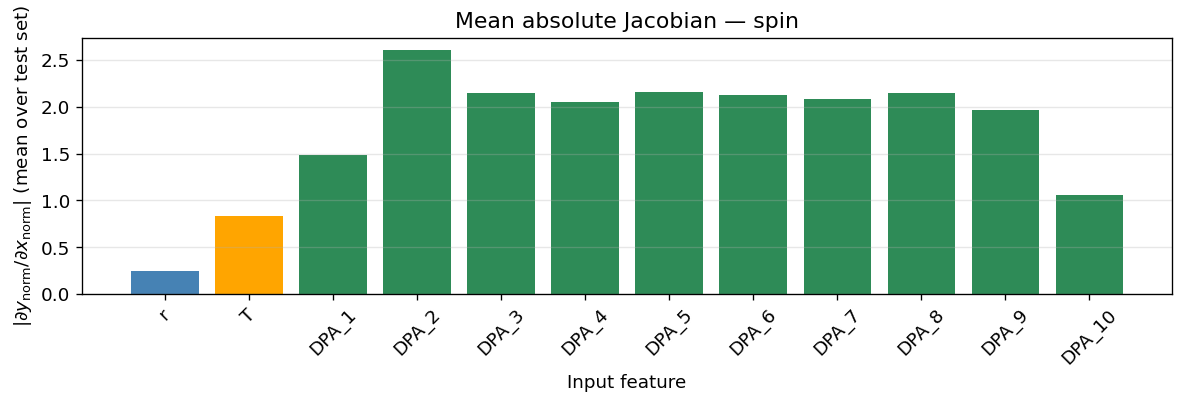

In [46]:
mean_abs_J = np.mean(np.abs(jacobians_array), axis=0)  # (12,)

fig, ax = plt.subplots(figsize=(10, 3.5))
colors_bar = ["steelblue", "orange"] + ["seagreen"] * 10
ax.bar(feature_names, mean_abs_J, color=colors_bar)
ax.set_xlabel("Input feature")
ax.set_ylabel(r"$|\partial y_\mathrm{norm} / \partial x_\mathrm{norm}|$ (mean over test set)")
ax.set_title(f"Mean absolute Jacobian — {JACOBIAN_TARGET}")
ax.tick_params(axis="x", rotation=45)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()